In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## BÀI 2

Using device: cuda
Loading datasets...
Vocabulary size: 2516
Labels: {'negative': 0, 'neutral': 1, 'positive': 2}

Model architecture:
FiveLayerGRU(
  (embedding): Embedding(2516, 128, padding_idx=0)
  (gru1): GRU(128, 256, batch_first=True, bidirectional=True)
  (gru2): GRU(512, 256, batch_first=True, bidirectional=True)
  (gru3): GRU(512, 256, batch_first=True, bidirectional=True)
  (gru4): GRU(512, 256, batch_first=True, bidirectional=True)
  (gru5): GRU(512, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)

Total parameters: 5,647,363

Starting training...
Epoch 1/20
  Train Loss: 0.6946, Train F1: 0.4459
  Dev Loss: 0.4408, Dev F1: 0.5891
  → New best model saved! (Dev F1: 0.5891)
Epoch 2/20
  Train Loss: 0.3527, Train F1: 0.6033
  Dev Loss: 0.3070, Dev F1: 0.7300
  → New best model saved! (Dev F1: 0.7300)
Epoch 3/20
  Train Loss: 0.2802, Train F1: 0.6636
  Dev Loss: 0.3082, Dev F1: 0

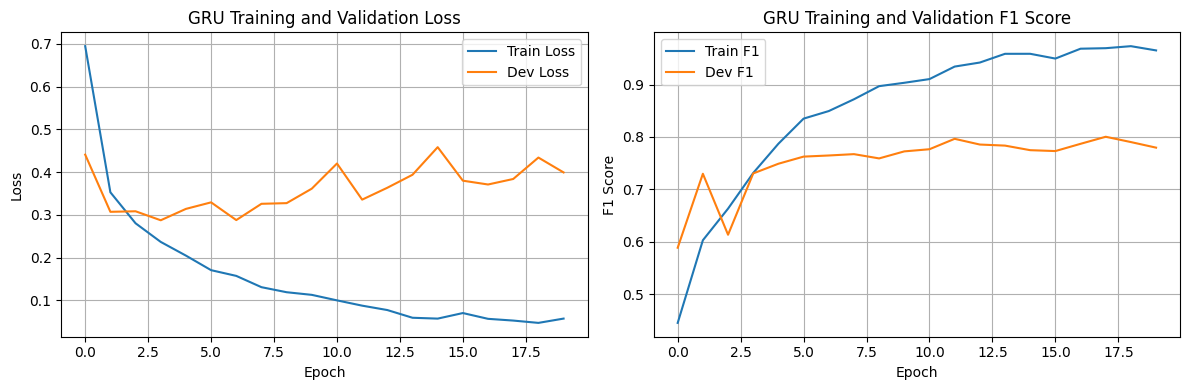

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import json
import numpy as np
from sklearn.metrics import f1_score, classification_report
from collections import Counter
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class Vocabulary:
    """Build vocabulary from training data"""
    def __init__(self, max_vocab_size=20000):
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2word = {0: "<PAD>", 1: "<UNK>"}
        self.max_vocab_size = max_vocab_size

    def build_vocab(self, sentences):
        """Build vocabulary from list of sentences"""
        word_freq = Counter()
        for sentence in sentences:
            words = sentence.lower().split()
            word_freq.update(words)

        # Keep most common words
        most_common = word_freq.most_common(self.max_vocab_size - 2)

        for idx, (word, _) in enumerate(most_common, start=2):
            self.word2idx[word] = idx
            self.idx2word[idx] = word

        print(f"Vocabulary size: {len(self.word2idx)}")

    def encode(self, sentence):
        """Convert sentence to list of indices"""
        words = sentence.lower().split()
        return [self.word2idx.get(word, 1) for word in words]  # 1 is <UNK>


class VSFCDataset(Dataset):
    """Dataset class for UIT-VSFC"""
    def __init__(self, file_path, vocab=None, label_encoder=None, is_train=False):
        with open(file_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        self.sentences = [item['sentence'] for item in self.data]
        self.labels = [item['sentiment'] for item in self.data]

        # Build vocabulary on training set
        if is_train:
            self.vocab = Vocabulary()
            self.vocab.build_vocab(self.sentences)

            # Build label encoder
            unique_labels = sorted(set(self.labels))
            self.label_encoder = {label: idx for idx, label in enumerate(unique_labels)}
            print(f"Labels: {self.label_encoder}")
        else:
            self.vocab = vocab
            self.label_encoder = label_encoder

        # Encode sentences and labels
        self.encoded_sentences = [self.vocab.encode(sent) for sent in self.sentences]
        self.encoded_labels = [self.label_encoder[label] for label in self.labels]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.encoded_sentences[idx]), torch.tensor(self.encoded_labels[idx])


def collate_fn(batch):
    """Custom collate function to pad sequences"""
    sentences, labels = zip(*batch)
    sentences_padded = pad_sequence(sentences, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return sentences_padded, labels


class FiveLayerGRU(nn.Module):
    """5-layer GRU for text classification"""
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, dropout=0.5):
        super(FiveLayerGRU, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # 5 GRU layers
        self.gru1 = nn.GRU(embedding_dim, hidden_size, batch_first=True, bidirectional=True)
        self.gru2 = nn.GRU(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.gru3 = nn.GRU(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.gru4 = nn.GRU(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.gru5 = nn.GRU(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # Embedding layer
        embedded = self.embedding(x)

        # Pass through 5 GRU layers
        out, _ = self.gru1(embedded)
        out = self.dropout(out)

        out, _ = self.gru2(out)
        out = self.dropout(out)

        out, _ = self.gru3(out)
        out = self.dropout(out)

        out, _ = self.gru4(out)
        out = self.dropout(out)

        out, _ = self.gru5(out)

        # Use the last hidden state
        out = out[:, -1, :]
        out = self.dropout(out)

        # Classification layer
        out = self.fc(out)
        return out


def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for sentences, labels in dataloader:
        sentences, labels = sentences.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(sentences)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1


def evaluate(model, dataloader, criterion, device):
    """Evaluate the model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for sentences, labels in dataloader:
            sentences, labels = sentences.to(device), labels.to(device)

            outputs = model(sentences)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1, all_preds, all_labels


def main():
    # Hyperparameters
    EMBEDDING_DIM = 128
    HIDDEN_SIZE = 256
    BATCH_SIZE = 32
    NUM_EPOCHS = 20
    LEARNING_RATE = 0.001

    # Load datasets
    print("Loading datasets...")
    train_dataset = VSFCDataset('/content/drive/MyDrive/DATASET/UIT-VSFC/UIT-VSFC-train.json', is_train=True)
    dev_dataset = VSFCDataset('/content/drive/MyDrive/DATASET/UIT-VSFC/UIT-VSFC-dev.json',
                              vocab=train_dataset.vocab,
                              label_encoder=train_dataset.label_encoder)
    test_dataset = VSFCDataset('/content/drive/MyDrive/DATASET/UIT-VSFC/UIT-VSFC-test.json',
                               vocab=train_dataset.vocab,
                               label_encoder=train_dataset.label_encoder)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, collate_fn=collate_fn)
    dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                            shuffle=False, collate_fn=collate_fn)

    # Initialize model
    vocab_size = len(train_dataset.vocab.word2idx)
    num_classes = len(train_dataset.label_encoder)

    model = FiveLayerGRU(vocab_size, EMBEDDING_DIM, HIDDEN_SIZE, num_classes).to(device)
    print(f"\nModel architecture:\n{model}")
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Training loop
    best_dev_f1 = 0
    train_losses, dev_losses = [], []
    train_f1s, dev_f1s = [], []

    print("\nStarting training...")
    for epoch in range(NUM_EPOCHS):
        train_loss, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        dev_loss, dev_f1, _, _ = evaluate(model, dev_loader, criterion, device)

        train_losses.append(train_loss)
        dev_losses.append(dev_loss)
        train_f1s.append(train_f1)
        dev_f1s.append(dev_f1)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        print(f"  Train Loss: {train_loss:.4f}, Train F1: {train_f1:.4f}")
        print(f"  Dev Loss: {dev_loss:.4f}, Dev F1: {dev_f1:.4f}")

        # Save best model
        if dev_f1 > best_dev_f1:
            best_dev_f1 = dev_f1
            torch.save(model.state_dict(), 'best_gru_model.pt')
            print(f"  → New best model saved! (Dev F1: {dev_f1:.4f})")

    # Load best model and evaluate on test set
    print("\n" + "="*50)
    print("Loading best model for test evaluation...")
    model.load_state_dict(torch.load('best_gru_model.pt'))
    test_loss, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

    print(f"\nTest Results:")
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test F1 (Macro): {test_f1:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(test_labels, test_preds,
                                target_names=[k for k, v in sorted(train_dataset.label_encoder.items(),
                                                                   key=lambda x: x[1])]))

    # Plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(dev_losses, label='Dev Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('GRU Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_f1s, label='Train F1')
    plt.plot(dev_f1s, label='Dev F1')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('GRU Training and Validation F1 Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('gru_training_curves.png', dpi=300, bbox_inches='tight')
    print("\nTraining curves saved as 'gru_training_curves.png'")


if __name__ == "__main__":
    main()

Sử dụng kỹ thuật early stopping

Using device: cuda
Loading datasets...
Vocabulary size: 2516
Labels: {'negative': 0, 'neutral': 1, 'positive': 2}

Model architecture:
FiveLayerGRU(
  (embedding): Embedding(2516, 128, padding_idx=0)
  (gru1): GRU(128, 256, batch_first=True, bidirectional=True)
  (gru2): GRU(512, 256, batch_first=True, bidirectional=True)
  (gru3): GRU(512, 256, batch_first=True, bidirectional=True)
  (gru4): GRU(512, 256, batch_first=True, bidirectional=True)
  (gru5): GRU(512, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)

Total parameters: 5,647,363

Starting training with early stopping (patience=7)...
Epoch 1/50
  Train Loss: 0.6946, Train F1: 0.4459
  Dev Loss: 0.4408, Dev F1: 0.5891
  → Validation F1 improved (0.5891 --> 0.5891). Saving model...
Epoch 2/50
  Train Loss: 0.3527, Train F1: 0.6033
  Dev Loss: 0.3070, Dev F1: 0.7300
  → Validation F1 improved (0.7300 --> 0.7300). Saving model...
Epoc

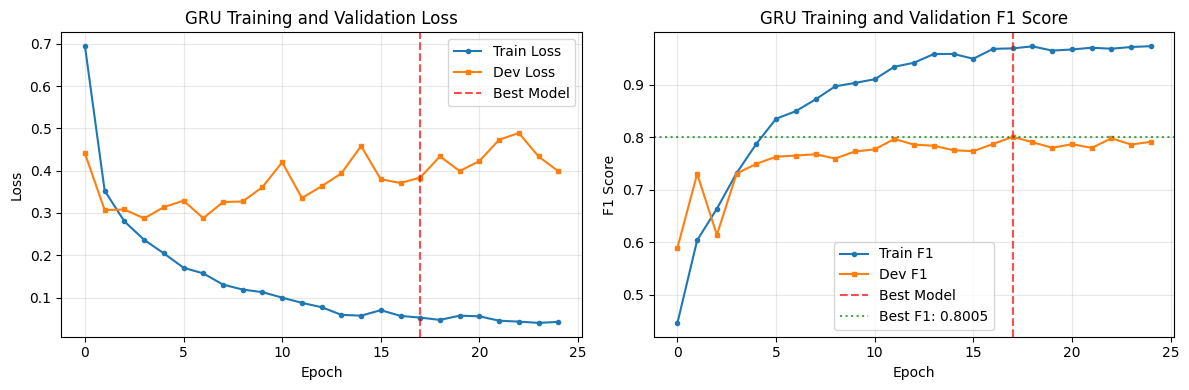

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import json
import numpy as np
from sklearn.metrics import f1_score, classification_report
from collections import Counter
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class EarlyStopping:
    """Early stopping to stop training when validation F1 doesn't improve"""
    def __init__(self, patience=5, min_delta=0.0001, verbose=True):
        """
        Args:
            patience (int): How many epochs to wait after last improvement
            min_delta (float): Minimum change to qualify as an improvement
            verbose (bool): Print messages when saving model
        """
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_f1 = 0

    def __call__(self, val_f1, model, path='best_gru_model.pt'):
        """Check if should stop training and save best model"""
        score = val_f1

        if self.best_score is None:
            # First epoch
            self.best_score = score
            self.best_f1 = val_f1
            self.save_checkpoint(val_f1, model, path)
        elif score < self.best_score + self.min_delta:
            # No improvement
            self.counter += 1
            if self.verbose:
                print(f'  EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            # Improvement
            self.best_score = score
            self.best_f1 = val_f1
            self.save_checkpoint(val_f1, model, path)
            self.counter = 0

    def save_checkpoint(self, val_f1, model, path):
        """Save model when validation F1 improves"""
        if self.verbose:
            print(f'  → Validation F1 improved ({self.best_f1:.4f} --> {val_f1:.4f}). Saving model...')
        torch.save(model.state_dict(), path)
        self.best_f1 = val_f1


class Vocabulary:
    """Build vocabulary from training data"""
    def __init__(self, max_vocab_size=20000):
        self.word2idx = {"<PAD>": 0, "<UNK>": 1}
        self.idx2word = {0: "<PAD>", 1: "<UNK>"}
        self.max_vocab_size = max_vocab_size

    def build_vocab(self, sentences):
        """Build vocabulary from list of sentences"""
        word_freq = Counter()
        for sentence in sentences:
            words = sentence.lower().split()
            word_freq.update(words)

        # Keep most common words
        most_common = word_freq.most_common(self.max_vocab_size - 2)

        for idx, (word, _) in enumerate(most_common, start=2):
            self.word2idx[word] = idx
            self.idx2word[idx] = word

        print(f"Vocabulary size: {len(self.word2idx)}")

    def encode(self, sentence):
        """Convert sentence to list of indices"""
        words = sentence.lower().split()
        return [self.word2idx.get(word, 1) for word in words]  # 1 is <UNK>


class VSFCDataset(Dataset):
    """Dataset class for UIT-VSFC"""
    def __init__(self, file_path, vocab=None, label_encoder=None, is_train=False):
        with open(file_path, 'r', encoding='utf-8') as f:
            self.data = json.load(f)

        self.sentences = [item['sentence'] for item in self.data]
        self.labels = [item['sentiment'] for item in self.data]

        # Build vocabulary on training set
        if is_train:
            self.vocab = Vocabulary()
            self.vocab.build_vocab(self.sentences)

            # Build label encoder
            unique_labels = sorted(set(self.labels))
            self.label_encoder = {label: idx for idx, label in enumerate(unique_labels)}
            print(f"Labels: {self.label_encoder}")
        else:
            self.vocab = vocab
            self.label_encoder = label_encoder

        # Encode sentences and labels
        self.encoded_sentences = [self.vocab.encode(sent) for sent in self.sentences]
        self.encoded_labels = [self.label_encoder[label] for label in self.labels]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.encoded_sentences[idx]), torch.tensor(self.encoded_labels[idx])


def collate_fn(batch):
    """Custom collate function to pad sequences"""
    sentences, labels = zip(*batch)
    sentences_padded = pad_sequence(sentences, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return sentences_padded, labels


class FiveLayerGRU(nn.Module):
    """5-layer GRU for text classification"""
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, dropout=0.5):
        super(FiveLayerGRU, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # 5 GRU layers
        self.gru1 = nn.GRU(embedding_dim, hidden_size, batch_first=True, bidirectional=True)
        self.gru2 = nn.GRU(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.gru3 = nn.GRU(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.gru4 = nn.GRU(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)
        self.gru5 = nn.GRU(hidden_size * 2, hidden_size, batch_first=True, bidirectional=True)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # Embedding layer
        embedded = self.embedding(x)

        # Pass through 5 GRU layers
        out, _ = self.gru1(embedded)
        out = self.dropout(out)

        out, _ = self.gru2(out)
        out = self.dropout(out)

        out, _ = self.gru3(out)
        out = self.dropout(out)

        out, _ = self.gru4(out)
        out = self.dropout(out)

        out, _ = self.gru5(out)

        # Use the last hidden state
        out = out[:, -1, :]
        out = self.dropout(out)

        # Classification layer
        out = self.fc(out)
        return out


def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for sentences, labels in dataloader:
        sentences, labels = sentences.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(sentences)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1


def evaluate(model, dataloader, criterion, device):
    """Evaluate the model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for sentences, labels in dataloader:
            sentences, labels = sentences.to(device), labels.to(device)

            outputs = model(sentences)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1, all_preds, all_labels


def main():
    # Hyperparameters
    EMBEDDING_DIM = 128
    HIDDEN_SIZE = 256
    BATCH_SIZE = 32
    NUM_EPOCHS = 50  # Increased since we'll use early stopping
    LEARNING_RATE = 0.001
    PATIENCE = 7  # Stop if no improvement for 7 epochs
    MIN_DELTA = 0.0001  # Minimum improvement to count as progress

    # Load datasets
    print("Loading datasets...")
    train_dataset = VSFCDataset('/content/drive/MyDrive/DATASET/UIT-VSFC/UIT-VSFC-train.json', is_train=True)
    dev_dataset = VSFCDataset('/content/drive/MyDrive/DATASET/UIT-VSFC/UIT-VSFC-dev.json',
                              vocab=train_dataset.vocab,
                              label_encoder=train_dataset.label_encoder)
    test_dataset = VSFCDataset('/content/drive/MyDrive/DATASET/UIT-VSFC/UIT-VSFC-test.json',
                               vocab=train_dataset.vocab,
                               label_encoder=train_dataset.label_encoder)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, collate_fn=collate_fn)
    dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                            shuffle=False, collate_fn=collate_fn)

    # Initialize model
    vocab_size = len(train_dataset.vocab.word2idx)
    num_classes = len(train_dataset.label_encoder)

    model = FiveLayerGRU(vocab_size, EMBEDDING_DIM, HIDDEN_SIZE, num_classes).to(device)
    print(f"\nModel architecture:\n{model}")
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Initialize early stopping
    early_stopping = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA, verbose=True)

    # Training loop
    train_losses, dev_losses = [], []
    train_f1s, dev_f1s = [], []

    print(f"\nStarting training with early stopping (patience={PATIENCE})...")
    for epoch in range(NUM_EPOCHS):
        train_loss, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        dev_loss, dev_f1, _, _ = evaluate(model, dev_loader, criterion, device)

        train_losses.append(train_loss)
        dev_losses.append(dev_loss)
        train_f1s.append(train_f1)
        dev_f1s.append(dev_f1)

        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        print(f"  Train Loss: {train_loss:.4f}, Train F1: {train_f1:.4f}")
        print(f"  Dev Loss: {dev_loss:.4f}, Dev F1: {dev_f1:.4f}")

        # Early stopping check
        early_stopping(dev_f1, model, path='best_gru_model.pt')

        if early_stopping.early_stop:
            print(f"\n{'='*50}")
            print(f"Early stopping triggered at epoch {epoch+1}")
            print(f"Best validation F1: {early_stopping.best_f1:.4f}")
            print(f"{'='*50}\n")
            break

    # Load best model and evaluate on test set
    print("Loading best model for test evaluation...")
    model.load_state_dict(torch.load('best_gru_model.pt'))
    test_loss, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

    print(f"\n{'='*50}")
    print(f"Final Test Results:")
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test F1 (Macro): {test_f1:.4f}")
    print(f"  Best Dev F1: {early_stopping.best_f1:.4f}")
    print(f"  Total Epochs Trained: {len(train_losses)}")
    print(f"{'='*50}")

    print("\nDetailed Classification Report:")
    print(classification_report(test_labels, test_preds,
                                target_names=[k for k, v in sorted(train_dataset.label_encoder.items(),
                                                                   key=lambda x: x[1])]))

    # Plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
    plt.plot(dev_losses, label='Dev Loss', marker='s', markersize=3)
    plt.axvline(x=len(train_losses) - PATIENCE - 1, color='r', linestyle='--',
                label='Best Model', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('GRU Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(train_f1s, label='Train F1', marker='o', markersize=3)
    plt.plot(dev_f1s, label='Dev F1', marker='s', markersize=3)
    plt.axvline(x=len(train_f1s) - PATIENCE - 1, color='r', linestyle='--',
                label='Best Model', alpha=0.7)
    plt.axhline(y=early_stopping.best_f1, color='g', linestyle=':',
                label=f'Best F1: {early_stopping.best_f1:.4f}', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title('GRU Training and Validation F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('gru_training_curves_early_stopping.png', dpi=300, bbox_inches='tight')
    print("\nTraining curves saved as 'gru_training_curves_early_stopping.png'")


if __name__ == "__main__":
    main()